# projet quantique - essai de re création de l'algo de Grover

*réf de l'algo :* [notebook d'un algo de grover](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers)

## imports 

In [25]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

### création d'un circuit simple

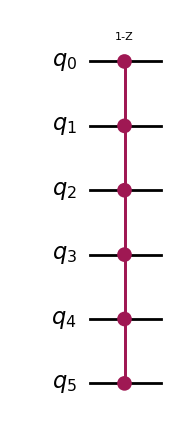

In [33]:
mcmt_ex = QuantumCircuit(6)
mcmt_ex.compose(MCMTGate(ZGate(), 6 - 1, 1), inplace=True)
mcmt_ex.draw(output="mpl", style="iqp")

### algo 

In [27]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])

    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bitstring to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bitstring
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bitstring has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    return qc

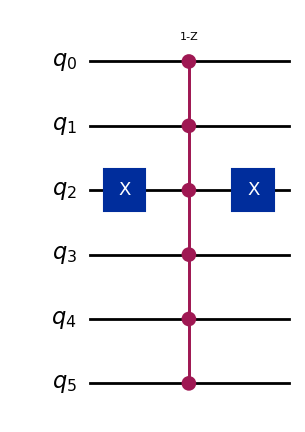

In [28]:
marked_states = ["111011"]
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

### affichage de grover + itérations

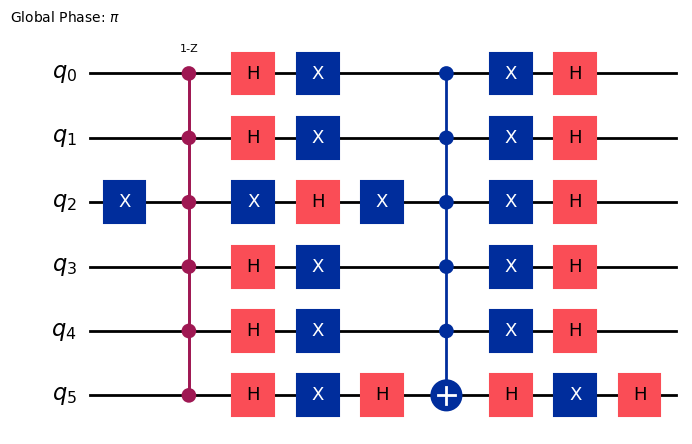

In [29]:
grover_op = grover_operator(oracle)
grover_op.decompose(reps=0).draw(output="mpl", style="iqp")

### optimal num iterations

In [30]:
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)
print(optimal_num_iterations)

6


### affichage final

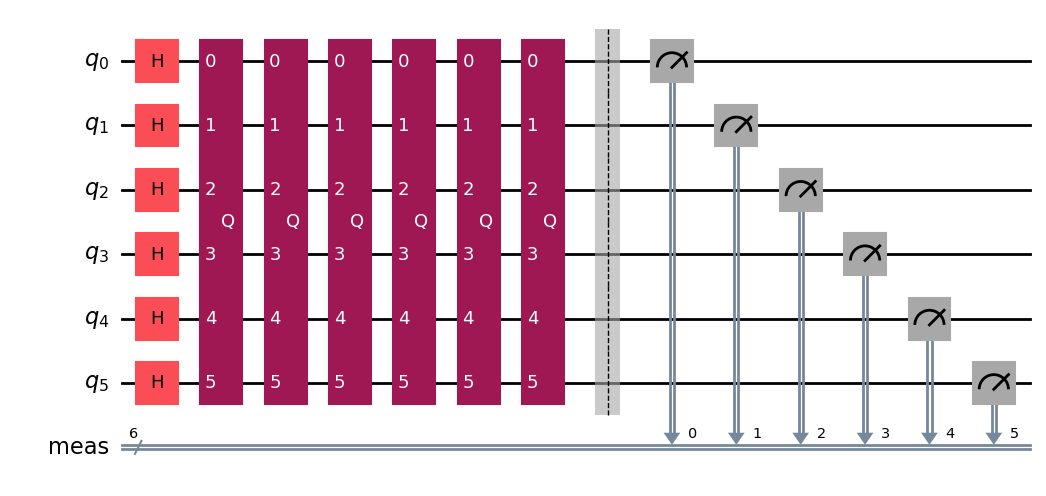

In [31]:
qc = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp")

### Gestion du Hardware 

**alors en gros j'ai l'impression que cette partie est pour simuler les "bruits" de l'ordi quantique et ainsi faire comme si on était 100% sur un ordi quantique?**

### Envoi à IBM

**je pense que ça sert à envoyer les données directement à IBM donc aux serveurs et tout et de ce que j'ai compris nous on va plutot faire en "simulation" que sur IBM donc ce code est mieux**

Résultats des mesures : {'111011': 1019, '000111': 1, '010111': 1, '001001': 1, '011100': 1, '100010': 1}


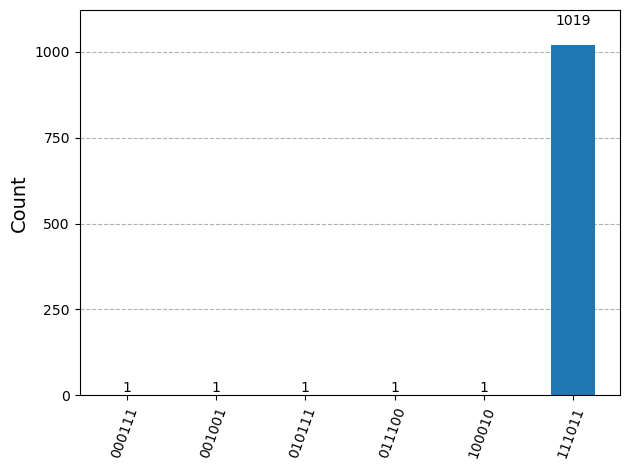

In [35]:
# 1. On initialise le simulateur
simulator = AerSimulator()

# 2. IMPORTANT : On décompose le circuit pour que le simulateur comprenne l'instruction 'Q'
# On peut le faire plusieurs fois pour être sûr d'arriver aux portes de base
qc_decomposed = qc.decompose().decompose().decompose()

# 3. On lance la simulation sur le circuit décomposé
job = simulator.run(qc_decomposed, shots=1024)
result = job.result()
counts = result.get_counts()

# 4. On affiche les résultats
print("Résultats des mesures :", counts)
plot_histogram(counts)

Remarque : je voulais "print" les valeurs à chaque itération pour pouvoir voir la valeur mais en quantique c'est impossible car tu peux pas observer une valeur car la mesure effondre l'état.